In [184]:
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.anova import AnovaRM
from statsmodels.formula.api import logit
from statsmodels.tools import add_constant

# Load and clean up data

### Debugg `jsonl` files

In [16]:
# groups = ['blocked', 'interleaved', 'free', 'post']
groups = ['blocked_easy']
for group in groups:
    pathin = f'pilots/{group}.jsonl'
    pathout = f'pilots/{group}_valid.jsonl'
    with open(pathin, 'rt') as fin:
        with open(pathout, 'wt') as fout:
            for line in fin:
                if "originalEvent" in line:
                    continue
                fout.write(line.replace('}{', '}\n{'))

### Create dataframe

In [97]:
# Identify condition for each participant and encode prolific PIDs
DF = pd.read_json("pilots/blocked_easy_valid.jsonl", lines=True)
# df['condition'] = df.groupby('prolificPID').transform(lambda s: s.iloc[0])
DF['pid'] = DF.prolificPID.astype('category').cat.codes

# # Drop unwanted columns and delete interim variables
DF = DF.drop(columns=['prolificStudyID', 'prolificPID'])

# # Drop participants with less than 216 trials in free stage
DF['numTrainTrials'] = df.groupby('pid')['feedbackOn'].transform(lambda s: s.sum())
display(DF.head())

,stage,feedbackOn,trialsComplete,famInd,features,rule,responseOrder,correctResponse,guess,confidence,correct,rt,pid,numTrainTrials
0,blocked_epochs,True,1,4,"[2, 3]",2d1,"[6, 7]",7,6,0.53,False,4804,25,72
1,blocked_epochs,True,2,4,"[6, 3]",2d1,"[6, 7]",6,7,0.79,False,3905,25,72
2,blocked_epochs,True,3,4,"[4, 4]",2d1,"[7, 6]",6,6,0.41,True,4792,25,72
3,blocked_epochs,True,4,4,"[6, 2]",2d1,"[7, 6]",6,7,0.53,False,4526,25,72
4,blocked_epochs,True,5,4,"[6, 1]",2d1,"[7, 6]",6,6,0.48,True,4038,25,72


In [48]:
np.histogram(df[df.feedbackOn].groupby('pid')[['famInd']].nunique(), bins=[1, 2, 3, 4])

(array([39,  0,  0]), array([1, 2, 3, 4]))

# Performance

Mean difference between conditions rules


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        correctCentered   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     50.04
Date:                Wed, 14 Dec 2022   Prob (F-statistic):           2.26e-08
Time:                        17:50:22   Log-Likelihood:                 31.521
No. Observations:                  39   AIC:                            -59.04
Df Residuals:                      37   BIC:                            -55.72
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.0380      0.025      1.497      0.143      -0.013       0.089
C(rule, Treatment("2d2"))[T.2d1]     0.2509      0.035      7.074      0.000       0.179       0.323
==============================================================================
Omnibus:                        3.606   Durbin-Watson:                   2.164
Prob(Omnibus):                  0.165   Jarque-Bera (JB):                2.340
Skew:                          -0.481   Prob(JB):                        0.310
Kurtosis:                       3.716   Cond. No.                         2.65
==============================================================================

  responseOrder  correctResponse  guess  confidence  correct     rt  \
0        [7, 6]                6      7        0.03    False  11536   
1        [7, 6]                6      6        0.18     True   3853   
2        [6, 7]                6      6        0.66     True   3879   
3        [7, 6]                7      7        1.00     True   4216   
4        [6, 7]                7      7        1.00     True   4184   

             condition  pid  numTrainTrials  
0  forced_blocked_1fam   11              72  
1  forced_blocked_1fam   11              72  
2  forced_blocked_1fam   11              72  
3  forced_blocked_1fam   11              72  
4  forced_blocked_1fam   11              72

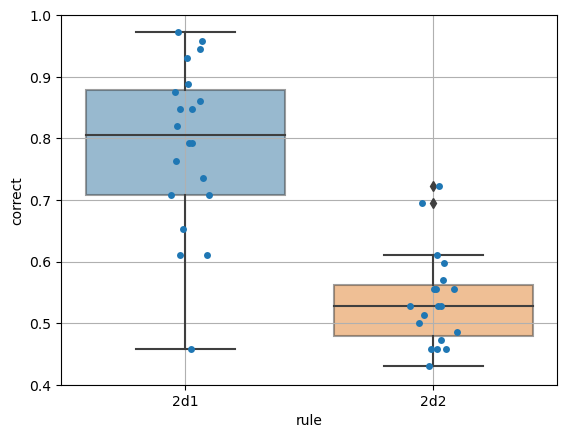

In [124]:
df = DF.groupby(['rule', 'pid', 'stage'])[['correct', 'confidence']].mean().reset_index()
fig = plt.figure('Performance')
ax = fig.add_subplot(111)
sns.boxplot(data=df, y='correct', x='rule', ax=ax, boxprops=dict(alpha=.5))
sns.stripplot(data=df, y='correct', x='rule', ax=ax, dodge=True)
ax.set_ylim(.4, 1.0)
ax.grid()


print('Mean difference between conditions rules')
df['correctCentered'] = df.correct - .5
display(sm.ols('correctCentered ~ C(rule, Treatment("2d2"))', data=df).fit().summary())

/var/folders/76/f7mjh1ks5339cvcfyvzxgmy00000gp/T/ipykernel_94252/534060948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['secondHalf'] = df.trialsComplete > 36


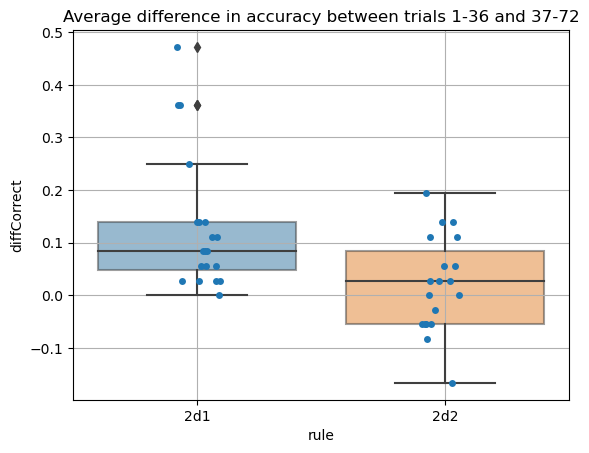

In [166]:
df = DF[['pid', 'rule', 'trialsComplete', 'correct', 'confidence']]
df['secondHalf'] = df.trialsComplete > 36
df = df.groupby(['rule', 'pid', 'secondHalf'])[['correct', 'confidence']].mean().reset_index()
diff_df = df.groupby(['rule', 'pid'])[['correct', 'confidence']].diff()
diff_df.columns = ['diffCorrect', 'diffConfidence']
df = df.join(diff_df).dropna()

fig = plt.figure('PerformanceDiff')
ax = fig.add_subplot(111)
sns.boxplot(data=df, y='diffCorrect', x='rule', ax=ax, boxprops=dict(alpha=.5))
sns.stripplot(data=df, y='diffCorrect', x='rule', ax=ax, dodge=True)
ax.grid()
ax.set_title('Average difference in accuracy between trials 1-36 and 37-72')
fig.savefig('plots/accuracyDiff.png')

# print('Mean difference between conditions rules')я
# df_['correctCentered'] = df_.correct - .5
# display(sm.ols('correctCentered ~ C(rule, Treatment("2d2"))', data=df_).fit().summary())

# Learning

/var/folders/76/f7mjh1ks5339cvcfyvzxgmy00000gp/T/ipykernel_94252/3868309738.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['correctInt'] = df.correct.astype(int)
/var/folders/76/f7mjh1ks5339cvcfyvzxgmy00000gp/T/ipykernel_94252/3868309738.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'correctSmooth{w}'] = df.correct.rolling(w, min_periods=1, win_type='hamming').mean()
/var/folders/76/f7mjh1ks5339cvcfyvzxgmy00000gp/T/ipykernel_94252/3868309738.py:6: SettingWithCopyWarning: 
A value is trying

,rule,trialsComplete,correct,confidence,correctInt,correctSmooth1,confidenceSmooth1
0,2d1,1,False,0.53,0,0.0,0.53
1,2d1,2,False,0.79,0,0.0,0.79
2,2d1,3,True,0.41,1,1.0,0.41
3,2d1,4,False,0.53,0,0.0,0.53
4,2d1,5,True,0.48,1,1.0,0.48


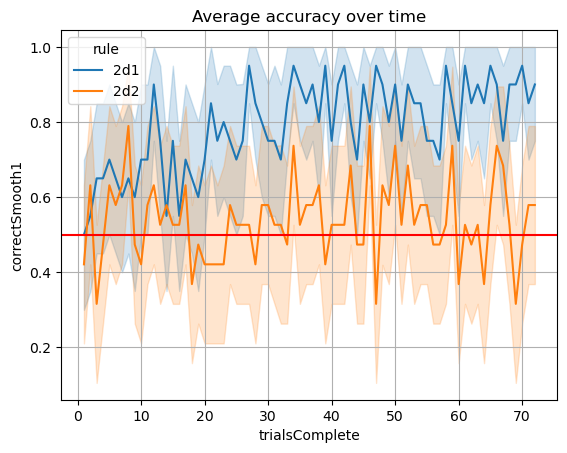

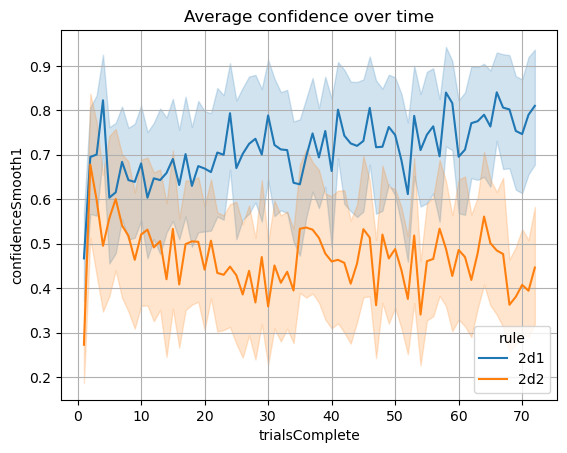

In [165]:
# df = df.groupby(['rule', 'trialsComplete'])[['correct', 'confidence']].agg(['mean', 'sem']).reset_index()
df = DF[['rule', 'trialsComplete', 'correct', 'confidence']]
df['correctInt'] = df.correct.astype(int)
w = 1
df[f'correctSmooth{w}'] = df.correct.rolling(w, min_periods=1, win_type='hamming').mean()
df[f'confidenceSmooth{w}'] = df.confidence.rolling(w, min_periods=1, win_type='hamming').mean()
display(df.head())

fig = plt.figure('LearningPerformance')
ax = fig.add_subplot(111)
sns.lineplot(data=df, y=f'correctSmooth{w}', x='trialsComplete', hue='rule', ax=ax)
ax.grid()
ax.set_title('Average accuracy over time')
ax.axhline(0.5, color='red')
fig.savefig('plots/groupLearningCurves.png')

fig = plt.figure('LearningConfidence')
ax = fig.add_subplot(111)
sns.lineplot(data=df, y=f'confidenceSmooth{w}', x='trialsComplete', hue='rule', ax=ax)
ax.grid()
ax.set_title('Average confidence over time')
fig.savefig('plots/groupConfidenceCurves.png')

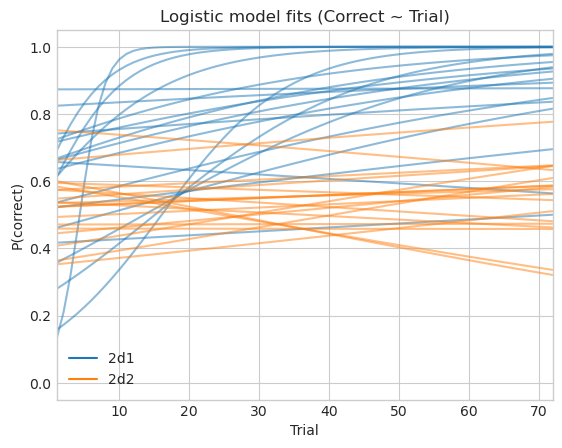

In [185]:
def fit_logmod(sdf):
    logmod = logit('correctInt ~ 1 + trialsComplete', data=sdf).fit(disp=0)
    b0, b1 = logmod.params
    return pd.Series(dict(b0=b0, b1=b1))


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


df = DF[['pid', 'rule', 'trialsComplete', 'correct', 'confidence']]
df = df.assign(correctInt=lambda sdf: sdf.correct.astype(int))
df = df.groupby(['rule', 'pid'])[['trialsComplete', 'correctInt']].apply(fit_logmod).reset_index()

with plt.style.context('seaborn-whitegrid'):
    fig = plt.figure('IndividualLearning')
    ax = fig.add_subplot(111)
    ax.set_xlim(1, 72)
    ax.set_ylim(-.05, 1.05)
    ax.set_xlabel('Trial')
    ax.set_ylabel('P(correct)')
    ax.set_title('Logistic model fits (Correct ~ Trial)')

    x = np.arange(1, 73)
    for i, row in df.iterrows():
        y = sigmoid(row.b0 + row.b1*x)
        ax.plot(x, y, color=get_cmap('tab10')(int(row.rule=='2d2')), alpha=.5)

    ax.legend(
        [Line2D([0], [0], color=get_cmap('tab10')(int(0))), Line2D([0], [0], color=get_cmap('tab10')(int(1)))], 
        ['2d1', '2d2'])

fig.savefig('plots/logmod_fits.png')


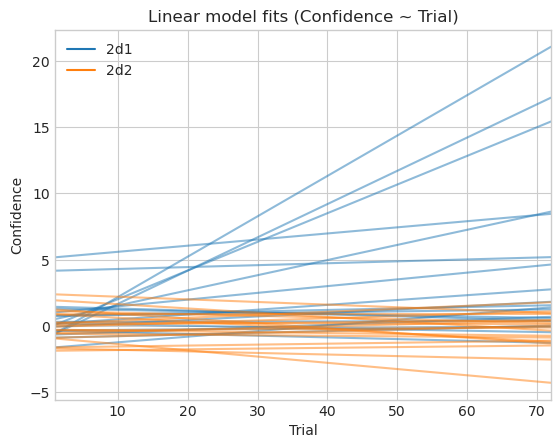

In [194]:
def fit_linmod(sdf):
    linmod = logit('confidence ~ 1 + trialsComplete', data=sdf).fit(disp=0)
    b0, b1 = linmod.params
    return pd.Series(dict(b0=b0, b1=b1))


df = DF[['pid', 'rule', 'trialsComplete', 'confidence']]
df = df.groupby(['rule', 'pid'])[['trialsComplete', 'confidence']].apply(fit_linmod).reset_index()

with plt.style.context('seaborn-whitegrid'):
    fig = plt.figure('IndividualLearning')
    ax = fig.add_subplot(111)
    ax.set_xlim(1, 72)
    # ax.set_ylim(-.05, 1.05)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Confidence')
    ax.set_title('Linear model fits (Confidence ~ Trial)')

    x = np.arange(1, 73)
    for i, row in df.iterrows():
        y = row.b0 + row.b1*x
        ax.plot(x, y, color=get_cmap('tab10')(int(row.rule=='2d2')), alpha=.5)

    ax.legend(
    [Line2D([0], [0], color=get_cmap('tab10')(int(0))), Line2D([0], [0], color=get_cmap('tab10')(int(1)))], 
    ['2d1', '2d2'])


fig.savefig('plots/linmod_fits.png')


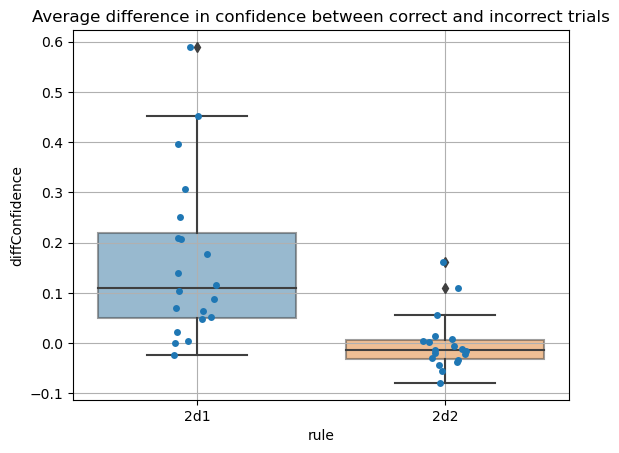

In [193]:
df = DF[['pid', 'rule', 'correct', 'confidence']]
df = df.assign(correctInt=lambda sdf: sdf.correct.astype(int))
df = df.groupby(['rule', 'pid', 'correct'])[['confidence']].mean().reset_index()
diff_df = df.groupby(['rule', 'pid'])[['confidence']].diff()
diff_df.columns = ['diffConfidence']
df = df.join(diff_df).dropna()

fig = plt.figure('PerformanceDiff')
ax = fig.add_subplot(111)
sns.boxplot(x='rule', y='diffConfidence', data=df, ax=ax, boxprops=dict(alpha=.5))
sns.stripplot(y='diffConfidence', x='rule', data=df, ax=ax, dodge=True)
ax.grid()
ax.set_title('Average difference in confidence between correct and incorrect trials')
fig.savefig('plots/confidenceDiff.png')

# sns.scatterplot(x=)

### Difference between test scores

Number of exclusions based on number of practice trials: 9
Mean difference in improvement between conditions


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                pc_diff   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.6819
Date:                Wed, 16 Nov 2022   Prob (F-statistic):              0.510
Time:                        13:10:16   Log-Likelihood:                 74.665
No. Observations:                  53   AIC:                            -143.3
Df Residuals:                      50   BIC:                            -137.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0114      0.015      0.769      0.446      -0.018       0.041
condition_[T.free]           -0.0237      0.020     -1.167      0.249      -0.065       0.017
condition_[T.interleaved]    -0.0115      0.021     -0.553      0.583      -0.053       0.030
==============================================================================
Omnibus:                        1.539   Durbin-Watson:                   2.538
Prob(Omnibus):                  0.463   Jarque-Bera (JB):                1.138
Skew:                          -0.077   Prob(JB):                        0.566
Kurtosis:                       2.299   Cond. No.                         3.80
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

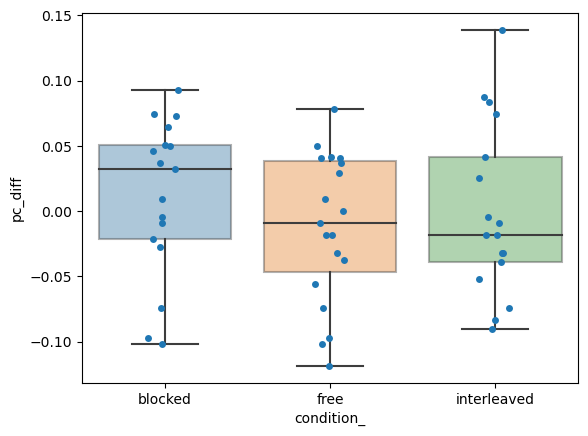

In [42]:
excl = len(df[df.numTrainTrials.lt(200)]['pid'].unique())
print(f'Number of exclusions based on number of practice trials: {excl}')
df_ = df[~df.feedbackOn & df.numTrainTrials.ge(200)].groupby(['condition', 'pid', 'stage'])[['correct', 'confidence']].mean().reset_index()
wide = pd.pivot(df_, index=['pid', 'condition'], columns='stage', values=['correct', 'confidence']).dropna().reset_index()
wide.columns = ['_'.join(col).strip() for col in wide.columns.values]
wide['pc_diff'] = wide.correct_test2 - wide.correct_test1
wide['conf_diff'] = wide.confidence_test2 - wide.confidence_test1
# wide.columns = ['pid', 'pc1, conf1', 'pc2', 'conf2']

fig = plt.figure('Diff')
ax = fig.add_subplot(111)
sns.boxplot(data=wide.sort_values(by='condition_'), y='pc_diff', x='condition_', ax=ax, boxprops=dict(alpha=0.4))
sns.stripplot(data=wide.sort_values(by='condition_'), y='pc_diff', x='condition_', ax=ax)

print('Mean difference in improvement between conditions')
display(sm.ols('pc_diff ~ condition_', data=wide).fit().summary())

# Learning

<AxesSubplot:xlabel='beta', ylabel='Count'>

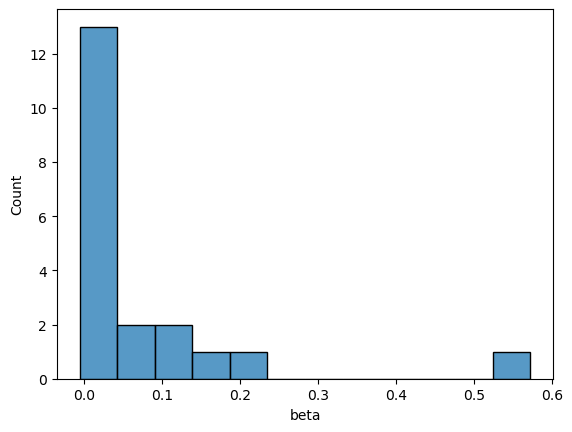

In [6]:
def fit_betas(df):
    y = df.correct.to_numpy().astype(int)
    x = df.trialsComplete.to_numpy().astype(int)
    try:
        logmod = Logit(y, add_constant(x)).fit(disp=0)
        beta = logmod.params[1]
    except:
        beta = np.nan
    return beta

df_ = df[df.stage.str.contains('epochs') & df.numTrainTrials.ge(20)].groupby(['pid'])[['correct', 'trialsComplete']].apply(fit_betas).reset_index()
df_ = df_.rename(columns={0: 'beta'}).fillna(0.0)

# sns.boxplot(data=df_, x='condition', y='beta', hue='famInd', showfliers = False, boxprops=dict(alpha=0.4))
# sns.stripplot(data=df_, x='condition', y='beta', hue='famInd', dodge=True)
# plt.gca().grid()
# plt.gca().set_ylim(-.035, .035)

sns.histplot(x='beta', data=df_)

,trialsComplete,correct,confidence
0,1,0.50,0.4670
1,2,0.55,0.6950
2,3,0.65,0.7005
3,4,0.65,0.8225
4,5,0.70,0.6035


<AxesSubplot:xlabel='trialsComplete', ylabel='confidence'>

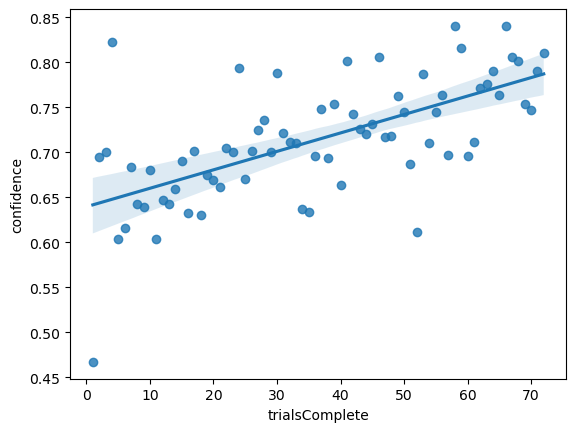

In [10]:
df_ = df.groupby('trialsComplete')[['correct', 'confidence']].mean().reset_index()
display(df_.head())
plt.figure()
sns.regplot(x='trialsComplete', y='confidence', data=df_)

<AxesSubplot:xlabel='correct', ylabel='Count'>

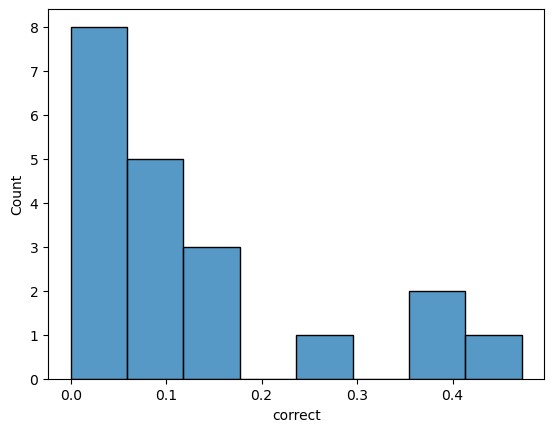

In [8]:
def diff(df):
    l = len(df)
    return -df.iloc[0:l//2].mean() + df.iloc[l//2:].mean()

df_ = df.groupby('pid')[['correct', 'confidence']].apply(diff)
sns.histplot(data=df_, x='correct')
